# EasyOCR + BLIP vs. Qwen2-VL — Extraction-Quality Evaluation on DocVQA
**Project:** Multimodal RAG Educational Assistant
**Student:** Omar Dahab — 23100704

Compares two **extraction** methods feeding the *same* downstream RAG pipeline, so the
comparison isolates extraction quality rather than mixing in "direct VQA vs. RAG":

- **Method A** — EasyOCR + BLIP (`backend/pipeline/loader.py::load_image`, unchanged)
- **Method B** — `Qwen/Qwen2-VL-2B-Instruct`, prompted to *describe/transcribe* the
  document (not answer the question). Extraction retries on detected degenerate output
  (bare bounding-box coordinates, or a markdown table with no data filled in) and falls
  back to greedy decoding on the final attempt — see `is_degenerate()` below.

For each method, the extracted text is run through the project's actual pipeline:
`preprocess()` → `embed()` → per-sample FAISS index → `retrieve()` → `generate()`
(`backend/pipeline/preprocessor.py`, `embedder.py`, `retriever.py`, `generator.py`).
The **final generated answer** — not the raw extraction — is what gets scored.

**Per sample, per method:**
- `extraction_time_sec` — time to extract text/caption/description from the image
- `pipeline_time_sec` — time for preprocess+embed+retrieve+generate on top of that extraction
- `exact_match` — does the final answer contain the ground-truth answer string?
- `token_f1` — word-overlap F1 between the final answer and the ground-truth answer
- `manual_quality` — left blank (1/2/3) for you to fill in after reading the outputs

Qwen2-VL runs on whatever device `backend/pipeline/device.py::get_torch_device()` resolves
to (Intel Arc GPU via `SA_DEVICE=gpu`, if the XPU torch wheel is installed — otherwise CPU).
`generator.py` already includes the flan-t5 number/time spacing cleanup fix.

In [3]:
import sys, os, re, time, ast, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

sys.path.append(str(Path('..').resolve()))
from backend.pipeline.loader import load_image

EVAL_SET_DIR = Path('../data/raw/docvqa_eval25')
RESULTS_DIR = Path('../data/eval')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
print('Setup OK')

Setup OK


## 1. Load the locally-saved 25-sample evaluation set

Pre-extracted once from `lmms-lab/DocVQA` (validation split) into
`data/raw/docvqa_eval25/` — `eval_set.csv` (question, answers, image filename) plus
`images/*.png`. No streaming/download needed on subsequent runs.

In [4]:
eval_df = pd.read_csv(EVAL_SET_DIR / 'eval_set.csv')

samples = []
for _, row in eval_df.iterrows():
    samples.append({
        'questionId': row['question_id'],
        'question': row['question'],
        'answers': json.loads(row['answers']),
        'image': Image.open(EVAL_SET_DIR / 'images' / row['image_filename']),
    })

print(f'Loaded {len(samples)} samples')
samples[0]['question'], samples[0]['answers']

Loaded 25 samples


('What is the ‘actual’ value per 1000, during the year 1975?', ['0.28'])

## 2. Metrics — Exact Match (containment) and Token F1

In [5]:
def normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def best_over_answers(pred_text: str, gt_answers: list, fn) -> float:
    """DocVQA has multiple acceptable answers — score against each, keep the best."""
    return max(fn(pred_text, gt) for gt in gt_answers)


def exact_match(pred_text: str, gt_answer: str) -> int:
    return int(normalize(gt_answer) in normalize(pred_text))


def token_f1(pred_text: str, gt_answer: str) -> float:
    pred_tokens = normalize(pred_text).split()
    gt_tokens = normalize(gt_answer).split()
    if not pred_tokens or not gt_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

print('Metrics defined')

Metrics defined


## 3. Method A — EasyOCR + BLIP (existing pipeline)

In [6]:
def run_ocr_blip(pil_image) -> tuple:
    """load_image() needs a file path — the saved sample PNG's own path is reused directly."""
    start = time.time()
    extraction = load_image(pil_image.filename)
    elapsed = time.time() - start
    return extraction, elapsed

print('run_ocr_blip defined')

run_ocr_blip defined


## 4. Method B — Qwen2-VL-2B-Instruct (extraction only, with retry/fallback)

In [7]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from backend.pipeline.device import get_torch_device

QWEN_MODEL_ID = 'Qwen/Qwen2-VL-2B-Instruct'
qwen_device = get_torch_device()

print(f'Loading Qwen2-VL on device={qwen_device} (first run downloads ~4GB)...')
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    torch_dtype=torch.float16 if qwen_device == 'xpu' else torch.float32,
    low_cpu_mem_usage=True,
)
qwen_model.to(qwen_device)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
print('Qwen2-VL loaded')

Loading Qwen2-VL on device=xpu (first run downloads ~4GB)...


[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[loader] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[loader] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/config.json "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/model.safetensors.index.json "HTTP/1.1 307 Temporary Redirect"
[loader] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/model.safetensors.index.json "HTTP/1.1 200 OK"
[loader] HTTP Request: GET https://huggingface.co/api/models/Qwen/Qw

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
[loader] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/generation_config.json "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[loader] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/preprocessor_config.json "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Qwen/Qwen

Qwen2-VL loaded


In [ ]:
EXTRACTION_PROMPT = (
    "Transcribe all visible text and numerical data in this document image, and describe any "
    "charts, tables, or figures. If there is a trend or relationship in the "
    "data, write all the numbers and explain it."
)

MAX_EXTRACTION_ATTEMPTS = 3
EXTRACTION_MAX_NEW_TOKENS = 640  # raised from 256


def is_degenerate(text: str) -> bool:
    """Detects three known Qwen2-VL failure modes on this task: bare
    bounding-box-style coordinate output, markdown tables with no real data
    filled in (just headers/pipes), and a long run of an identical near-empty
    line (e.g. hundreds of repeated "|  |  |" rows) appended after otherwise-
    genuine content — the whole-text word/pipe ratio check below doesn't catch
    this since the genuine prefix dilutes it."""
    stripped = text.strip()
    if not stripped:
        return True
    if re.fullmatch(r'[\s()\d,]+', stripped):
        return True
    pipe_count = stripped.count('|')
    word_count = len(re.findall(r'[A-Za-z]{3,}', stripped))
    if pipe_count > 10 and word_count < 8:
        return True
    lines = [l.strip() for l in stripped.splitlines() if l.strip()]
    if len(lines) >= 8:
        most_common_line, freq = Counter(lines).most_common(1)[0]
        if freq >= 8 and len(most_common_line) <= 20:
            return True
    return False


def _qwen2vl_generate_once(inputs, do_sample: bool) -> str:
    with torch.no_grad():
        kwargs = dict(max_new_tokens=EXTRACTION_MAX_NEW_TOKENS, eos_token_id=qwen_processor.tokenizer.eos_token_id)
        if do_sample:
            kwargs.update(do_sample=True, temperature=0.7, top_p=0.8, top_k=20, repetition_penalty=1.05)
        else:
            kwargs.update(do_sample=False)
        output_ids = qwen_model.generate(**inputs, **kwargs)
    generated_ids = output_ids[:, inputs['input_ids'].shape[1]:]
    return qwen_processor.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )[0].strip()


def run_qwen2vl_extraction(pil_image) -> tuple:
    """Extraction-only — Qwen2-VL describes/transcribes the document, never sees the
    question. Retries on degenerate output, falling back to greedy decoding on the
    final attempt (greedy proved more reliable than sampling on images that trigger
    the bbox/empty-table bug)."""
    messages = [{
        'role': 'user',
        'content': [{'type': 'image'}, {'type': 'text', 'text': EXTRACTION_PROMPT}],
    }]
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_processor(
        text=[text_prompt], images=[pil_image.convert('RGB')],
        padding=True, return_tensors='pt',
    ).to(qwen_device)

    start = time.time()
    extraction = ''
    for attempt in range(MAX_EXTRACTION_ATTEMPTS):
        do_sample = attempt < MAX_EXTRACTION_ATTEMPTS - 1
        extraction = _qwen2vl_generate_once(inputs, do_sample=do_sample)
        if not is_degenerate(extraction):
            break
    elapsed = time.time() - start
    return extraction, elapsed


print('run_qwen2vl_extraction defined')

run_qwen2vl_extraction defined


## 5. Shared downstream RAG pipeline

Both methods' extracted text is run through the project's actual pipeline functions —
this is what isolates extraction quality as the only variable.

In [18]:
import faiss

from backend.pipeline.preprocessor import preprocess
from backend.pipeline.embedder import embed
from backend.pipeline.retriever import retrieve
from backend.pipeline.generator import generate


def run_rag_pipeline(extracted_text: str, question: str, k: int = 3) -> tuple:
    """preprocess -> embed -> per-sample FAISS index -> retrieve -> generate."""
    start = time.time()
    try:
        chunks = preprocess(extracted_text)
    except ValueError:
        # preprocessor.preprocess() rejects text under 20 chars (OCR/extraction
        # likely failed) — record an empty answer rather than crashing the loop.
        return '', time.time() - start

    if not chunks:
        return '', time.time() - start

    chunk_embeddings = embed(chunks)
    index = faiss.IndexFlatL2(chunk_embeddings.shape[1])
    index.add(np.ascontiguousarray(chunk_embeddings, dtype=np.float32))

    retrieved_chunks = retrieve(question, index, chunks, k=k)
    answer = generate(question, retrieved_chunks)
    elapsed = time.time() - start
    return answer, elapsed

print('run_rag_pipeline defined')

run_rag_pipeline defined


In [19]:
sample0 = samples[0]
question = sample0['question']
gt_answers = sample0['answers']
image0 = sample0['image']

print(f"Sample 0 question: {question}")
print(f"Ground truth answers: {gt_answers}\n")

ocr_blip_extraction, ocr_blip_extraction_time = run_ocr_blip(image0)
ocr_blip_final_answer, ocr_blip_pipeline_time = run_rag_pipeline(ocr_blip_extraction, question)

qwen_extraction, qwen_extraction_time = run_qwen2vl_extraction(image0)
qwen_final_answer, qwen_pipeline_time = run_rag_pipeline(qwen_extraction, question)

results = {
    'ocr_blip_extraction': ocr_blip_extraction,
    'ocr_blip_extraction_time_sec': ocr_blip_extraction_time,
    'ocr_blip_final_answer': ocr_blip_final_answer,
    'ocr_blip_pipeline_time_sec': ocr_blip_pipeline_time,
    'ocr_blip_exact_match': best_over_answers(ocr_blip_final_answer, gt_answers, exact_match),
    'ocr_blip_token_f1': best_over_answers(ocr_blip_final_answer, gt_answers, token_f1),
    'qwen2vl_extraction': qwen_extraction,
    'qwen2vl_extraction_time_sec': qwen_extraction_time,
    'qwen2vl_final_answer': qwen_final_answer,
    'qwen2vl_pipeline_time_sec': qwen_pipeline_time,
    'qwen2vl_exact_match': best_over_answers(qwen_final_answer, gt_answers, exact_match),
    'qwen2vl_token_f1': best_over_answers(qwen_final_answer, gt_answers, token_f1),
}

print(json.dumps(results, indent=2))

[loader] Processing image → ..\data\raw\docvqa_eval25\images\sample_00.png


Sample 0 question: What is the ‘actual’ value per 1000, during the year 1975?
Ground truth answers: ['0.28']



[loader] OCR complete — 218 characters extracted
[loader] BLIP caption: a black and white photo of a line graph


{
  "ocr_blip_extraction": "Extracted text: FIGURF C.2 _\nAgeAdJusted Hotor UEHESHRDACCIDENT MORTALITY Rate\n0.3\n0.28\n1 0.26\n1\n0.24\n0.22\n0.2\n1950 1955 1960 1965 1970 1975 1980\nActuAL\n88a MULTIVARIATE]_PREDICTOR\nSourger hlyps lindustrdocuments ueskeduldocshpybv0228\n\nImage description: a black and white photo of a line graph",
  "ocr_blip_extraction_time_sec": 3.018970012664795,
  "ocr_blip_final_answer": "0.3 0.28",
  "ocr_blip_pipeline_time_sec": 0.337522029876709,
  "ocr_blip_exact_match": 1,
  "ocr_blip_token_f1": 0.6666666666666666,
  "qwen2vl_extraction": "(10,10),(988,987)",
  "qwen2vl_extraction_time_sec": 154.6872477531433,
  "qwen2vl_final_answer": "",
  "qwen2vl_pipeline_time_sec": 0.0,
  "qwen2vl_exact_match": 0,
  "qwen2vl_token_f1": 0.0
}


## 6. Run both methods (extraction + full pipeline) over the sample set

In [8]:
rows = []
for i, sample in enumerate(samples):
    question = sample['question']
    gt_answers = sample['answers']
    image = sample['image']

    print(f'[{i+1}/{len(samples)}] {question}')

    # Method A — EasyOCR + BLIP extraction, then shared pipeline
    ocr_blip_extraction, ocr_blip_extraction_time = run_ocr_blip(image)
    ocr_blip_answer, ocr_blip_pipeline_time = run_rag_pipeline(ocr_blip_extraction, question)

    # Method B — Qwen2-VL extraction (question-agnostic), then shared pipeline
    qwen_extraction, qwen_extraction_time = run_qwen2vl_extraction(image)
    qwen_answer, qwen_pipeline_time = run_rag_pipeline(qwen_extraction, question)

    rows.append({
        'sample_idx': i,
        'question_id': sample.get('questionId', ''),
        'question': question,
        'ground_truth_answers': gt_answers,

        'ocr_blip_extraction': ocr_blip_extraction,
        'ocr_blip_extraction_time_sec': round(ocr_blip_extraction_time, 2),
        'ocr_blip_final_answer': ocr_blip_answer,
        'ocr_blip_pipeline_time_sec': round(ocr_blip_pipeline_time, 2),
        'ocr_blip_exact_match': best_over_answers(ocr_blip_answer, gt_answers, exact_match),
        'ocr_blip_token_f1': round(best_over_answers(ocr_blip_answer, gt_answers, token_f1), 3),
        'ocr_blip_manual_quality': None,

        'qwen2vl_extraction': qwen_extraction,
        'qwen2vl_extraction_time_sec': round(qwen_extraction_time, 2),
        'qwen2vl_final_answer': qwen_answer,
        'qwen2vl_pipeline_time_sec': round(qwen_pipeline_time, 2),
        'qwen2vl_exact_match': best_over_answers(qwen_answer, gt_answers, exact_match),
        'qwen2vl_token_f1': round(best_over_answers(qwen_answer, gt_answers, token_f1), 3),
        'qwen2vl_manual_quality': None,
    })

results_df = pd.DataFrame(rows)
results_df.head()

[loader] Processing image → ..\data\raw\docvqa_eval25\images\sample_00.png


[1/25] What is the ‘actual’ value per 1000, during the year 1975?


[loader] Loading EasyOCR reader (first use)...
[loader] Patched torch.nn.DataParallel -> passthrough for XPU (no multi-GPU scatter)
[loader] OCR complete — 218 characters extracted
[loader] Loading BLIP image-captioning model (first use)...
[loader] HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/audio_tokenizer_config.jso

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[loader] HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
[loader] HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[loader] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
[loader] HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/refs%2Fpr%2F52 "HTTP/1.1 200 OK"
[loader] HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/refs%2Fpr%2F52/mo

...

[24/25] What time is “introductory remarks” session?


[loader] OCR complete — 1119 characters extracted
[loader] BLIP caption: a black and white menu with a list of items
[loader] Processing image → ..\data\raw\docvqa_eval25\images\sample_24.png


[25/25] Why Taco Bell's strong consumer base decreased?


[loader] OCR complete — 261 characters extracted
[loader] BLIP caption: a document with the text, ' ' ' ' ' and ' ' ' '


,sample_idx,question_id,question,ground_truth_answers,ocr_blip_extraction,ocr_blip_extraction_time_sec,ocr_blip_final_answer,ocr_blip_pipeline_time_sec,ocr_blip_exact_match,ocr_blip_token_f1,ocr_blip_manual_quality,qwen2vl_extraction,qwen2vl_extraction_time_sec,qwen2vl_final_answer,qwen2vl_pipeline_time_sec,qwen2vl_exact_match,qwen2vl_token_f1,qwen2vl_manual_quality
0,0,49153,"What is the ‘actual’ value per 1000, during th...",[0.28],Extracted text: FIGURF C.2 _\nAgeAdJusted Hoto...,15.70,0.3 0.28,12.66,1,0.667,None,Figure C.2: Age Adjusted Motor Vehicle Acciden...,62.80,age adjusted motor vehicle accident mortality ...,1.05,0,0.0,None
1,1,24580,What is name of university?,"[university of california, University of Calif...","Extracted text: UNIVERSITY OPGALIEORNIA , SAN ...",3.35,ucsf,0.50,0,0.000,None,The document appears to be a memo or a message...,15.45,"university of california, san diego",1.14,1,1.0,None
2,2,57349,What is the name of the company?,"[itc limited, ITC Limited]",Extracted text: ITC Limited REPORT AND ACCOUNT...,9.51,itc,0.42,0,0.667,None,"(75,157),(368,411)",136.00,,0.00,0,0.0,None
3,3,24581,Where is the university located ?,"[san diego, San Diego]","Extracted text: UNIVERSITY OPGALIEORNIA , SAN ...",1.60,"opgalieornia, san dieco",1.11,0,0.400,None,The image appears to be a scanned document fro...,30.29,san diego,0.70,1,1.0,None
4,4,24582,To whom is the document sent?,[Paul],"Extracted text: UNIVERSITY OPGALIEORNIA , SAN ...",1.55,mr,0.35,0,0.000,None,"UNIVERSITY OF CALIFORNIA, SAN DIEGO\n\nTo: Pau...",13.47,paul,0.31,1,1.0,None


## 7. Save results — fill in the `*_manual_quality` columns (1/2/3) after reviewing outputs

In [9]:
out_path = RESULTS_DIR / 'easyocr_blip_vs_qwen2vl_results.csv'
results_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')
print('Open this CSV, fill in ocr_blip_manual_quality / qwen2vl_manual_quality (1=absent, 2=partial, 3=present),')
print('then re-load it below to regenerate the summary with manual scores included.')

Saved → ..\data\eval\easyocr_blip_vs_qwen2vl_results.csv
Open this CSV, fill in ocr_blip_manual_quality / qwen2vl_manual_quality (1=absent, 2=partial, 3=present),
then re-load it below to regenerate the summary with manual scores included.


## 8. Summary comparison

In [10]:
# Re-load in case manual_quality columns were filled in and saved back to the CSV
if out_path.exists():
    results_df = pd.read_csv(out_path)

results_df['ocr_blip_total_time_sec'] = (
    results_df['ocr_blip_extraction_time_sec'] + results_df['ocr_blip_pipeline_time_sec']
)
results_df['qwen2vl_total_time_sec'] = (
    results_df['qwen2vl_extraction_time_sec'] + results_df['qwen2vl_pipeline_time_sec']
)

summary = pd.DataFrame({
    'easyocr_blip': [
        results_df['ocr_blip_exact_match'].mean(),
        results_df['ocr_blip_token_f1'].mean(),
        results_df['ocr_blip_total_time_sec'].mean(),
        results_df['ocr_blip_manual_quality'].mean(),
    ],
    'qwen2vl': [
        results_df['qwen2vl_exact_match'].mean(),
        results_df['qwen2vl_token_f1'].mean(),
        results_df['qwen2vl_total_time_sec'].mean(),
        results_df['qwen2vl_manual_quality'].mean(),
    ],
}, index=['exact_match', 'token_f1', 'avg_time_sec', 'avg_manual_quality'])

summary

,easyocr_blip,qwen2vl
exact_match,0.32000,0.60000
token_f1,0.52552,0.62052
avg_time_sec,7.90160,64.60120
avg_manual_quality,NaN,NaN


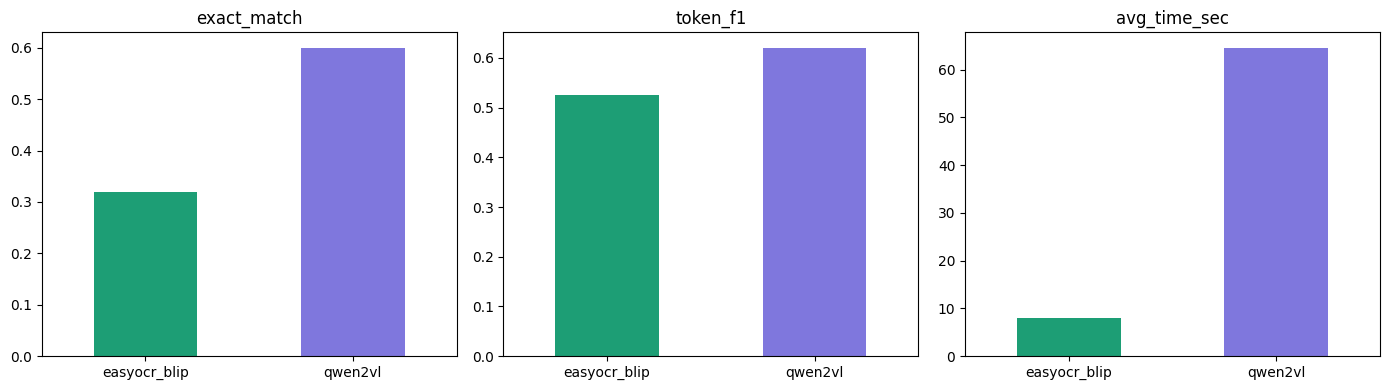

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = ['exact_match', 'token_f1', 'avg_time_sec']
for ax, metric in zip(axes, metrics_to_plot):
    summary.loc[metric].plot(kind='bar', ax=ax, color=['#1D9E75', '#7F77DD'])
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'easyocr_blip_vs_qwen2vl_summary.png', bbox_inches='tight')
plt.show()